In [44]:
# Core
import pandas as pd
import numpy as np

# Data fetching
import yfinance as yf

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Feature engineering
from ta.momentum import RSIIndicator
from ta.volatility import AverageTrueRange

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import RobustScaler


# Model
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import optuna
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [ ]:
# Download Gold and DXY data
gold = yf.download("GC=F", start="1970-01-01")
dxy = yf.download("DX-Y.NYB", start="1970-01-01")

# Keep only the Close price from DXY
gold['DXY'] = dxy['Close']

gold.dropna(inplace=True)

print(gold.shape)
print(gold.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(6441, 6)
Price            Close        High         Low        Open Volume         DXY
Ticker            GC=F        GC=F        GC=F        GC=F   GC=F            
Date                                                                         
2000-08-30  273.899994  273.899994  273.899994  273.899994      0  112.139999
2000-08-31  278.299988  278.299988  274.799988  274.799988      0  112.599998
2000-09-01  277.000000  277.000000  277.000000  277.000000      0  111.419998
2000-09-05  275.799988  275.799988  275.799988  275.799988      2  112.410004
2000-09-06  274.200012  274.200012  274.200012  274.200012      0  114.120003


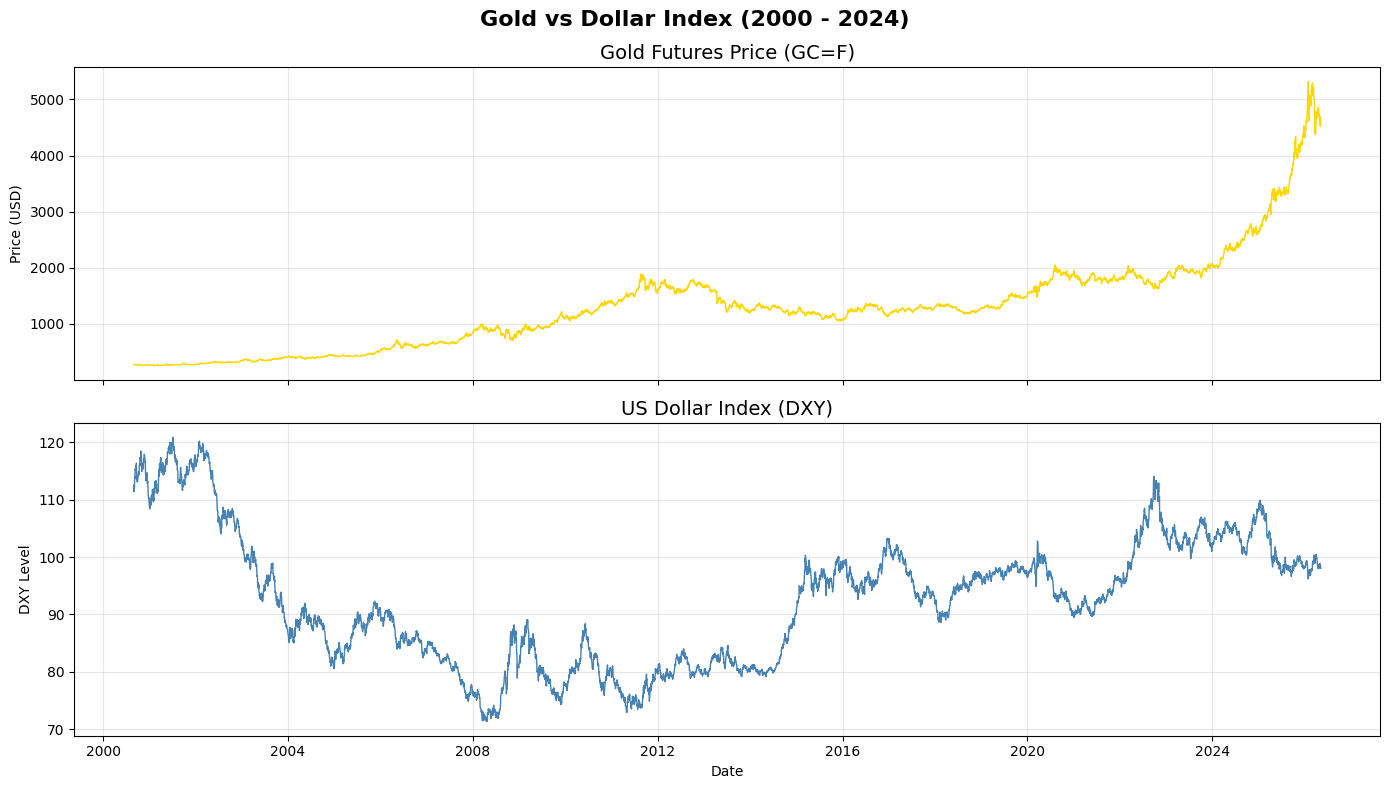

In [46]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Gold price
ax1.plot(gold.index, gold['Close'], color='gold', linewidth=1)
ax1.set_title('Gold Futures Price (GC=F)', fontsize=14)
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

# DXY
ax2.plot(gold.index, gold['DXY'], color='steelblue', linewidth=1)
ax2.set_title('US Dollar Index (DXY)', fontsize=14)
ax2.set_ylabel('DXY Level')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)

plt.suptitle('Gold vs Dollar Index (2000 - 2024)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
gold.columns = [col[0] if isinstance(col, tuple) else col for col in gold.columns]

# Download Macro Data 
vix   = yf.download('^VIX',    start="1970-01-01")
tnx   = yf.download('^TNX',    start="1970-01-01")
sp500 = yf.download('^GSPC',   start="1970-01-01")
dxy   = yf.download('DX-Y.NYB',start="1970-01-01")

# Flatten Macro MultiIndex Columns
for df in [vix, tnx, sp500, dxy]:
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

# Add DXY 
gold['DXY_Return'] = np.log(dxy['Close'] / dxy['Close'].shift(1))

# Add VIX 
gold['VIX']        = vix['Close']
gold['VIX_Change'] = np.log(vix['Close'] / vix['Close'].shift(1))

# Add 10yr Treasury Yield 
gold['TNX']        = tnx['Close']
gold['TNX_Change'] = tnx['Close'].diff()

# Add S&P500 
gold['SP500_Return'] = np.log(sp500['Close'] / sp500['Close'].shift(1))

# Gold Specific Features 
gold['Log_Return']    = np.log(gold['Close'] / gold['Close'].shift(1))
gold['Return_Lag1']   = gold['Log_Return'].shift(1)
gold['Return_Lag2']   = gold['Log_Return'].shift(2)
gold['Return_Lag3']   = gold['Log_Return'].shift(3)

# RSI (14 day) 
gold['RSI14'] = RSIIndicator(close=gold['Close'], window=14).rsi()

# ATR (14 day) 
gold['ATR14'] = AverageTrueRange(
    high=gold['High'],
    low=gold['Low'],
    close=gold['Close'],
    window=14
).average_true_range()

# Realised volatility at different lookback windows
gold['RealVol5']  = gold['Log_Return'].rolling(5).std()   # 1 week
gold['RealVol21'] = gold['Log_Return'].rolling(21).std()  # 1 month

# ATR relative to its own history (is volatility high or low right now?)
gold['ATR_Ratio'] = gold['ATR14'] / gold['ATR14'].rolling(60).mean()

# Absolute size of recent moves (direct magnitude memory)
gold['AbsReturn_Lag1'] = np.abs(gold['Log_Return'].shift(1))
gold['AbsReturn_Lag2'] = np.abs(gold['Log_Return'].shift(2))

# Drop NaN rows
gold['Target'] = gold['Log_Return'].shift(-1)
gold.dropna(inplace=True)

print(gold.shape)
print(gold.head())
print("\nColumns:", gold.columns.tolist())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(6374, 24)
                 Close        High         Low        Open  Volume  \
Date                                                                 
2000-11-22  266.299988  266.299988  266.299988  266.299988       0   
2000-11-27  270.100006  270.100006  270.100006  270.100006       0   
2000-11-28  269.799988  269.799988  269.799988  269.799988   28696   
2000-11-29  266.399994  270.100006  265.799988  269.600006    2849   
2000-11-30  270.100006  270.200012  266.200012  266.399994     810   

                   DXY  DXY_Return        VIX  VIX_Change    TNX  ...  \
Date                                                              ...   
2000-11-22  117.849998   -0.000848  27.709999    0.040130  5.593  ...   
2000-11-27  117.099998   -0.011716  26.930000    0.035144  5.626  ...   
2000-11-28  116.580002   -0.004451  27.639999    0.026023  5.589  ...   
2000-11-29  116.610001    0.000257  27.490000   -0.005442  5.543  ...   
2000-11-30  115.239998   -0.011818  29.650000    0.075640  5

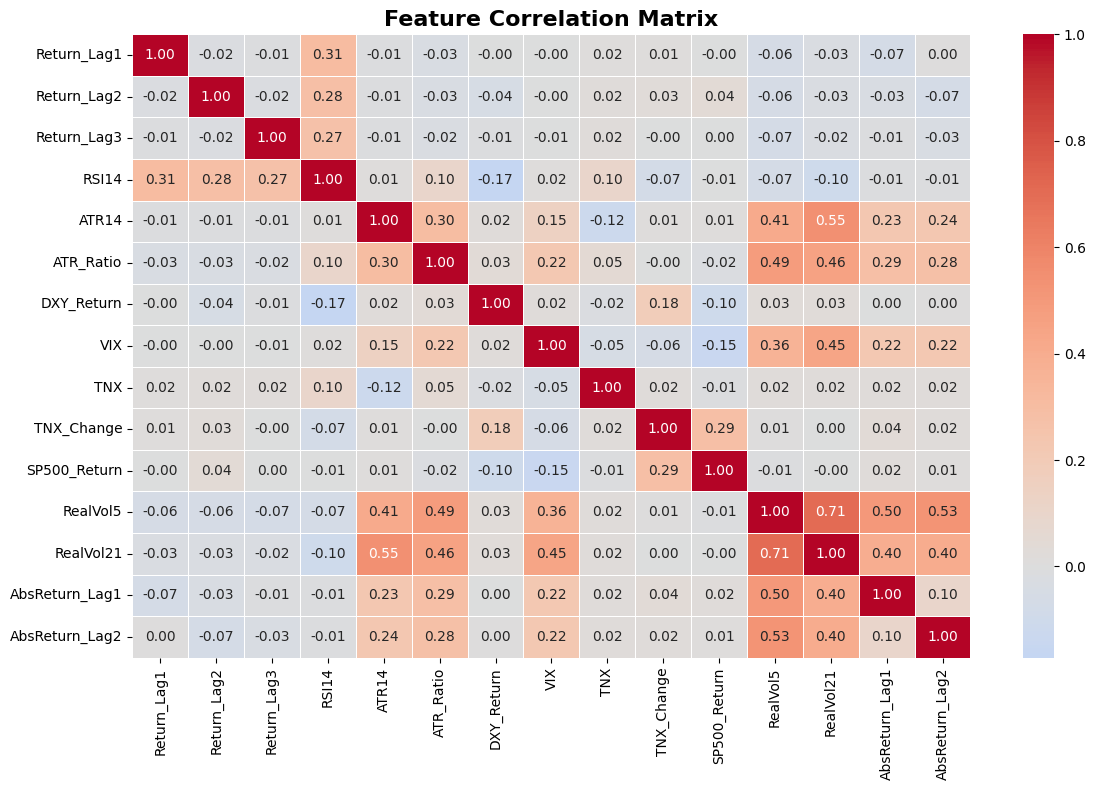


Highly Correlated Feature Pairs (>0.85):


In [ ]:
features = [
    'Return_Lag1', 'Return_Lag2', 'Return_Lag3',
    'RSI14', 'ATR14', 'ATR_Ratio',
    'DXY_Return', 'VIX', 'TNX', 'TNX_Change', 'SP500_Return',
    'RealVol5', 'RealVol21',
    'AbsReturn_Lag1', 'AbsReturn_Lag2'
]

corr_matrix = gold[features].corr()

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 10}
)

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print highly correlated pairs (above 0.85)
print("\nHighly Correlated Feature Pairs (>0.85):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            print(f"{corr_matrix.columns[i]} & {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.2f}")

features = [
    'Lag1_Close',    # Price memory
    'MA200',         # Long term trend
    'Log_Return',    # Price change
    'RSI14',         # Momentum
    'ATR14',         # Volatility
    'DXY'            # Macro driver
]

  Fold 1 Accuracy: 55.12%
  Fold 2 Accuracy: 47.00%
  Fold 3 Accuracy: 51.83%
  Fold 4 Accuracy: 51.12%
  Fold 5 Accuracy: 48.88%

  Walk-Forward Mean Accuracy : 50.79%
  Walk-Forward Std Dev       : 2.76%
 TIER 1 BASE MODEL (TWO-STAGE PIPELINE)
 Walk-Forward Accuracy (train) : 50.79% ± 2.76%
 Direction Accuracy  (test)    : 51.45%
 Combined MAE                  : 0.012032
 Combined RMSE                 : 0.016280


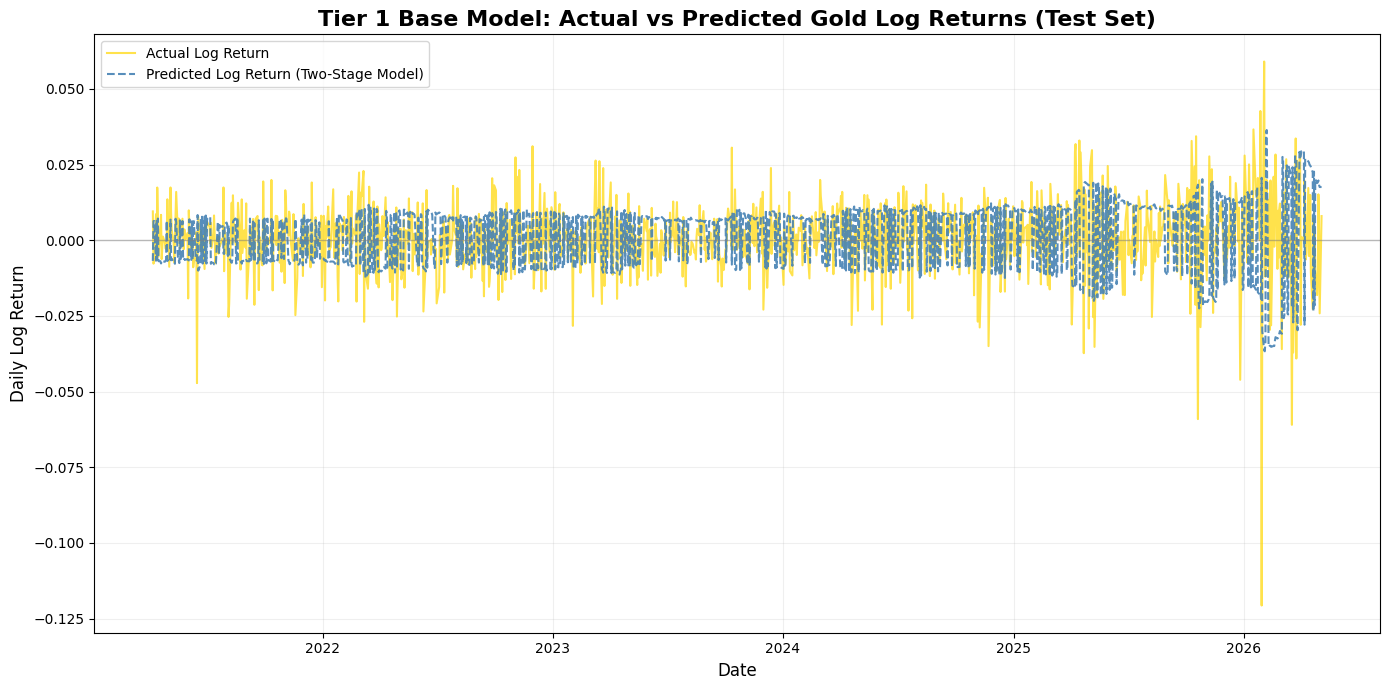

In [ ]:
# 1. Define Targets 
gold['Target_Return']    = gold['Log_Return'].shift(-1)
gold['Target_Direction'] = np.where(gold['Target_Return'] >= 0, 1, 0)
gold['Target_Magnitude'] = np.abs(gold['Target_Return'])
gold.dropna(inplace=True)

# 2. Define Features & Split Data 
# Log_Return removed to prevent target leakage (today's return predicting tomorrow's)
# VIX_Change removed due to high correlation with VIX
features = [
    'Return_Lag1', 'Return_Lag2', 'Return_Lag3',
    'RSI14', 'ATR14', 'ATR_Ratio',
    'DXY_Return', 'VIX', 'TNX', 'TNX_Change', 'SP500_Return',
    'RealVol5', 'RealVol21',
    'AbsReturn_Lag1', 'AbsReturn_Lag2'
]

X = gold[features]

# Chronological 80/20 split - no shuffling to preserve time order
split_idx = int(len(X) * 0.80)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train_dir = gold['Target_Direction'].iloc[:split_idx]
y_test_dir  = gold['Target_Direction'].iloc[split_idx:]

y_train_mag = gold['Target_Magnitude'].iloc[:split_idx]
y_test_mag  = gold['Target_Magnitude'].iloc[split_idx:]

y_test_raw  = gold['Target_Return'].iloc[split_idx:]

# 3. Scale Features
# Fit only on training data to prevent lookahead bias
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. Walk-Forward Validation (Direction Model) 
# 5 folds across the training set to assess stability across market regimes
# Each fold trains on the past and tests on the next unseen period
tscv = TimeSeriesSplit(n_splits=5)

clf_model = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000)

wf_scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_scaled)):
    X_fold_train = X_train_scaled[train_idx]
    X_fold_val   = X_train_scaled[val_idx]
    y_fold_train = y_train_dir.iloc[train_idx]
    y_fold_val   = y_train_dir.iloc[val_idx]

    clf_model.fit(X_fold_train, y_fold_train)
    fold_acc = accuracy_score(y_fold_val, clf_model.predict(X_fold_val))
    wf_scores.append(fold_acc)
    print(f"  Fold {fold+1} Accuracy: {fold_acc:.2%}")

print(f"\n  Walk-Forward Mean Accuracy : {np.mean(wf_scores):.2%}")
print(f"  Walk-Forward Std Dev       : {np.std(wf_scores):.2%}")

# 5. Final Train on Full Training Set 
# Retrain on all training data before evaluating on the held-out test set
clf_model.fit(X_train_scaled, y_train_dir)
y_pred_dir = clf_model.predict(X_test_scaled)
dir_accuracy = accuracy_score(y_test_dir, y_pred_dir)

# 6. Stage 2: Magnitude Regression
mag_model = LinearRegression()
mag_model.fit(X_train_scaled, y_train_mag)

y_pred_mag = mag_model.predict(X_test_scaled)
y_pred_mag = np.maximum(y_pred_mag, 0)

# 7. Combine Direction + Magnitude
direction_multipliers = np.where(y_pred_dir == 1, 1, -1)
final_predictions     = direction_multipliers * y_pred_mag

# 8. Evaluate
combined_mae  = mean_absolute_error(y_test_raw, final_predictions)
combined_rmse = np.sqrt(mean_squared_error(y_test_raw, final_predictions))

print("=" * 50)
print(" TIER 1 BASE MODEL (TWO-STAGE PIPELINE)")
print("=" * 50)
print(f" Walk-Forward Accuracy (train) : {np.mean(wf_scores):.2%} ± {np.std(wf_scores):.2%}")
print(f" Direction Accuracy  (test)    : {dir_accuracy:.2%}")
print(f" Combined MAE                  : {combined_mae:.6f}")
print(f" Combined RMSE                 : {combined_rmse:.6f}")
print("=" * 50)

# 9. Visualisation
plt.figure(figsize=(14, 7))

plt.plot(y_test_raw.index, y_test_raw.values,
         label='Actual Log Return',
         color='gold', alpha=0.7, linewidth=1.5)

plt.plot(y_test_raw.index, final_predictions,
         label='Predicted Log Return (Two-Stage Model)',
         color='steelblue', alpha=0.9, linestyle='--', linewidth=1.5)

plt.axhline(0, color='gray', linestyle='-', alpha=0.5, linewidth=1)
plt.title('Tier 1 Base Model: Actual vs Predicted Gold Log Returns (Test Set)',
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Log Return', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Define Features & Targets
features = [
    'Return_Lag1', 'Return_Lag2', 'Return_Lag3',
    'RSI14', 'ATR14', 'ATR_Ratio',
    'DXY_Return', 'VIX', 'TNX', 'TNX_Change', 'SP500_Return',
    'RealVol5', 'RealVol21',
    'AbsReturn_Lag1', 'AbsReturn_Lag2'
]

X     = gold[features]
y_raw = gold['Target_Return']
y_clf = gold['Target_Direction']
y_mag = np.abs(gold['Target_Return'])

# 2. Train/Test Split
split_idx = int(len(X) * 0.80)

X_train,     X_test     = X.iloc[:split_idx],     X.iloc[split_idx:]
y_train_clf, y_test_clf = y_clf.iloc[:split_idx], y_clf.iloc[split_idx:]
y_train_mag, y_test_mag = y_mag.iloc[:split_idx], y_mag.iloc[split_idx:]
y_test_raw              = y_raw.iloc[split_idx:]

print(f"Training set : {X_train.index[0].date()} to {X_train.index[-1].date()} ({len(X_train)} rows)")
print(f"Testing set  : {X_test.index[0].date()} to {X_test.index[-1].date()} ({len(X_test)} rows)")

# 3. Scale Features
scaler_xgb = RobustScaler()
X_train_scaled = scaler_xgb.fit_transform(X_train)
X_test_scaled  = scaler_xgb.transform(X_test)

# 4. Stage 1 Optuna — XGBoost Classifier (Direction)
# Optuna cross-validates inside the training set only
# Using TimeSeriesSplit to respect time ordering within the training set
tscv = TimeSeriesSplit(n_splits=5)

def objective_clf(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 2, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 1.0),
        'objective'        : 'binary:logistic',
        'eval_metric'      : 'logloss',
        'random_state'     : 42,
        'tree_method'      : 'hist'
    }
    fold_scores = []
    for train_idx, val_idx in tscv.split(X_train_scaled):
        model = xgb.XGBClassifier(**params)
        model.fit(X_train_scaled[train_idx], y_train_clf.iloc[train_idx], verbose=False)
        preds = model.predict(X_train_scaled[val_idx])
        fold_scores.append(accuracy_score(y_train_clf.iloc[val_idx], preds))
    return np.mean(fold_scores)

print("\nStage 1 — Running Optuna for XGBoost Classifier (100 trials)...")
study_clf = optuna.create_study(direction='maximize')
study_clf.optimize(objective_clf, n_trials=100)

best_clf_params = study_clf.best_params
best_clf_params.update({'objective': 'binary:logistic', 'eval_metric': 'logloss',
                        'random_state': 42, 'tree_method': 'hist'})

# Retrain on full training set with best params before evaluating on test set
xgb_clf = xgb.XGBClassifier(**best_clf_params)
xgb_clf.fit(X_train_scaled, y_train_clf)

y_pred_clf   = xgb_clf.predict(X_test_scaled)
dir_accuracy = accuracy_score(y_test_clf, y_pred_clf) * 100

print(f"\nStage 1 — XGBoost Classifier (Direction):")
print(f"Directional Accuracy : {dir_accuracy:.2f}%")

# 5. Stage 2 Optuna — XGBoost Regressor (Magnitude)
def objective_reg(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 2, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 1.0),
        'random_state'     : 42,
        'tree_method'      : 'hist'
    }
    fold_scores = []
    for train_idx, val_idx in tscv.split(X_train_scaled):
        model = xgb.XGBRegressor(**params)
        model.fit(X_train_scaled[train_idx], y_train_mag.iloc[train_idx], verbose=False)
        preds = model.predict(X_train_scaled[val_idx])
        fold_scores.append(mean_absolute_error(y_train_mag.iloc[val_idx], preds))
    return np.mean(fold_scores)

print("\nStage 2 — Running Optuna for XGBoost Regressor (100 trials)...")
study_reg = optuna.create_study(direction='minimize')
study_reg.optimize(objective_reg, n_trials=100)

best_reg_params = study_reg.best_params
best_reg_params.update({'random_state': 42, 'tree_method': 'hist'})

# Retrain on full training set with best params before evaluating on test set
xgb_reg = xgb.XGBRegressor(**best_reg_params)
xgb_reg.fit(X_train_scaled, y_train_mag)

y_pred_mag = xgb_reg.predict(X_test_scaled)
y_pred_mag = np.maximum(y_pred_mag, 0)

print(f"\nStage 2 — XGBoost Regressor (Magnitude):")
print(f"Magnitude MAE : {mean_absolute_error(y_test_mag, y_pred_mag):.6f}")

# 6. Synthesis (Combine Direction + Magnitude)
direction_multipliers      = np.where(y_pred_clf == 1, 1, -1)
final_combined_predictions = direction_multipliers * y_pred_mag

combined_mae  = mean_absolute_error(y_test_raw, final_combined_predictions)
combined_rmse = np.sqrt(mean_squared_error(y_test_raw, final_combined_predictions))

# 6b. Big Move Accuracy
# Evaluates directional accuracy on the top 20% largest actual moves
threshold    = np.percentile(np.abs(y_test_raw), 80)
big_move_idx = np.abs(y_test_raw) > threshold
big_move_acc = accuracy_score(
    np.sign(y_test_raw.values[big_move_idx]),
    np.sign(final_combined_predictions[big_move_idx])
)

print("\n" + "=" * 50)
print(" TIER 2 MODEL PERFORMANCE (COMBINED XGBOOST)")
print("=" * 50)
print(f" Direction Accuracy      : {dir_accuracy:.2f}%")
print(f" Big Move Accuracy (80th): {big_move_acc:.2%}")
print(f" Combined MAE            : {combined_mae:.6f}")
print(f" Combined RMSE           : {combined_rmse:.6f}")
print("=" * 50)

# 7. Plot Actual vs Predicted
plt.figure(figsize=(14, 6))

plt.plot(y_test_raw.index, y_test_raw.values,
         color='gold', linewidth=1.2, alpha=0.8, label='Actual Log Return')
plt.plot(y_test_raw.index, final_combined_predictions,
         color='steelblue', linewidth=1.2, linestyle='--', alpha=0.9,
         label='Predicted Log Return (Combined)')

plt.axhline(0, color='gray', linestyle='-', alpha=0.4)
plt.title('Tier 2 XGBoost — Actual vs Predicted Gold Returns', fontsize=14, fontweight='bold')
plt.ylabel('Daily Log Return')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Next Day Prediction
last_row        = X.iloc[[-1]]
last_row_scaled = scaler_xgb.transform(last_row)

prob_up        = xgb_clf.predict_proba(last_row_scaled)[0][1]
pred_direction = 1 if prob_up > 0.5 else -1
pred_magnitude = float(xgb_reg.predict(last_row_scaled)[0])
pred_magnitude = max(pred_magnitude, 0)

combined_predicted_return = pred_direction * pred_magnitude
last_known_price          = float(gold['Close'].iloc[-1])
next_day_price            = last_known_price * np.exp(combined_predicted_return)
direction_str             = "UP" if prob_up > 0.5 else "DOWN"

print("\n" + "=" * 50)
print("     NEXT DAY GOLD PREDICTION (TIER 2 XGBOOST)")
print("=" * 50)
print(f"  Last Known Price    : ${last_known_price:.2f}")
print(f"  Probability Up      : {prob_up:.2%}")
print(f"  Predicted Magnitude : {pred_magnitude:.6f}")
print(f"  Combined Return     : {combined_predicted_return:.6f}")
print(f"  Predicted Price     : ${next_day_price:.2f}")
print(f"  Expected Move ($)   : ${next_day_price - last_known_price:.2f}")
print(f"  Direction           : {direction_str}")
print("=" * 50)

Training set : 2000-11-22 to 2021-04-06 (5098 rows)
Testing set  : 2021-04-07 to 2026-05-04 (1275 rows)

Stage 1 — Running Optuna for XGBoost Classifier (100 trials)...


[W 2026-05-06 09:24:09,884] Trial 12 failed with parameters: {'n_estimators': 552, 'max_depth': 7, 'learning_rate': 0.010766428383862374, 'subsample': 0.8543018961264429, 'colsample_bytree': 0.7796790749648539, 'min_child_weight': 3, 'gamma': 0.8000019390580414} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\harry\anaconda3\envs\torch-gpu\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\harry\AppData\Local\Temp\ipykernel_8664\2003566614.py", line 58, in objective_clf
    model.fit(X_train_scaled[train_idx], y_train_clf.iloc[train_idx], verbose=False)
  File "c:\Users\harry\anaconda3\envs\torch-gpu\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\harry\anaconda3\envs\torch-gpu\Lib\site-packages\xgboost\sklearn.py", line 1806, in fit
    self._Booster

KeyboardInterrupt: 

Using device: cuda

Stage 1 — Running Optuna for Classifier LSTM (30 trials)...
Best Classifier Params : {'hidden_size_1': 128, 'hidden_size_2': 16, 'dropout': 0.12862343444466304, 'lr': 0.0002556060498230707, 'lookback': 5}
Best Lookback          : 5
Final Directional Accuracy: 51.26%

Stage 2 — Running Optuna for Regressor LSTM (30 trials)...
Best Regressor Params: {'hidden_size_1': 128, 'hidden_size_2': 64, 'dropout': 0.35052702396677793, 'lr': 0.0013517563078962532}

 TIER 3 MODEL PERFORMANCE (TWO-STAGE LSTM)
 Best Lookback           : 5 days
 Direction Accuracy      : 51.26%
 Big Move Accuracy (80th): 48.43%
 Combined MAE            : 0.012415
 Combined RMSE           : 0.017189


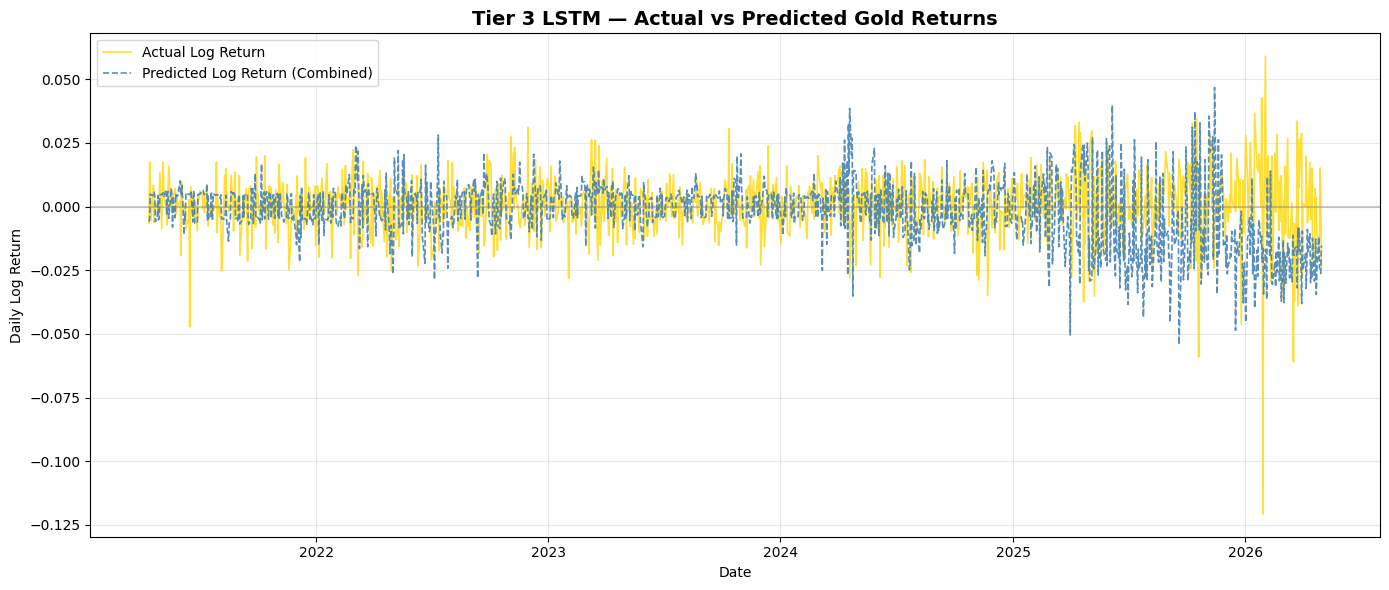


     NEXT DAY GOLD PREDICTION (TIER 3 LSTM)
  Last Known Price    : $4629.90
  Probability Up      : 23.77%
  Predicted Magnitude : 0.017821
  Combined Return     : -0.017821
  Predicted Price     : $4548.12
  Expected Move ($)   : $-81.78
  Direction           : DOWN


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import RobustScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Set Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Define Features & Targets
# Log_Return removed to prevent target leakage
# VIX_Change removed due to high correlation with VIX
# Volatility features added to improve magnitude prediction
lstm_features = [
    'Return_Lag1', 'Return_Lag2', 'Return_Lag3',
    'RSI14', 'ATR14', 'ATR_Ratio',
    'DXY_Return', 'VIX', 'TNX', 'TNX_Change', 'SP500_Return',
    'RealVol5', 'RealVol21',
    'AbsReturn_Lag1', 'AbsReturn_Lag2'
]

X     = gold[lstm_features]
y_raw = gold['Target_Return']
y_clf = np.where(y_raw >= 0, 1.0, 0.0)
y_mag = np.abs(y_raw.values)

# 3. Train/Test Split (80/20 Time Ordered)
split_idx = int(len(X) * 0.80)

X_train_raw, X_test_raw = X.iloc[:split_idx], X.iloc[split_idx:]

y_train_raw, y_test_raw = y_raw.iloc[:split_idx].values, y_raw.iloc[split_idx:].values
y_train_clf, y_test_clf = y_clf[:split_idx], y_clf[split_idx:]
y_train_mag, y_test_mag = y_mag[:split_idx], y_mag[split_idx:]

# 4. Scale Features
# RobustScaler consistent across all tiers, handles financial spikes better
scaler_lstm = RobustScaler()
X_train_scaled = scaler_lstm.fit_transform(X_train_raw)
X_test_scaled  = scaler_lstm.transform(X_test_raw)

# 5. Sequence Creation Function
# LOOKBACK is no longer fixed - Optuna will find the best value
def create_sequences(X, y_raw, y_clf, y_mag, lookback):
    Xs, y_raws, y_clfs, y_mags = [], [], [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        y_raws.append(y_raw[i])
        y_clfs.append(y_clf[i])
        y_mags.append(y_mag[i])
    return np.array(Xs), np.array(y_raws), np.array(y_clfs), np.array(y_mags)

# 6. Define LSTM Architecture
class GoldLSTM(nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, dropout):
        super(GoldLSTM, self).__init__()
        self.lstm1    = nn.LSTM(input_size, hidden_size_1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2    = nn.LSTM(hidden_size_1, hidden_size_2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.fc       = nn.Linear(hidden_size_2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out    = self.dropout1(out)
        out, _ = self.lstm2(out)
        out    = self.dropout2(out)
        out    = self.fc(out[:, -1, :])
        return out

# 7. Universal Training Function
def train_model(model, criterion, X_train, y_train, X_val, y_val,
                lr, batch_size, epochs, patience=5):
    dataset    = TensorDataset(X_train, y_train)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_weights     = None

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in dataloader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_weights)
    return model, best_val_loss

# 8. Stage 1: Optuna for Classifier (Direction)
# Lookback tuned alongside architecture parameters
# Optuna only ever sees the internal train/val split, never the test set
print("\nStage 1 — Running Optuna for Classifier LSTM (30 trials)...")

def objective_clf(trial):
    h1       = trial.suggest_int('hidden_size_1', 32, 128, step=32)
    h2       = trial.suggest_int('hidden_size_2', 16, 64,  step=16)
    dropout  = trial.suggest_float('dropout', 0.1, 0.5)
    lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    lookback = trial.suggest_int('lookback', 5, 30, step=5)

    X_tr_seq, _, y_tr_clf_seq, _ = create_sequences(
        X_train_scaled, y_train_raw, y_train_clf, y_train_mag, lookback)

    val_split = int(len(X_tr_seq) * 0.80)
    X_tr_t  = torch.tensor(X_tr_seq[:val_split], dtype=torch.float32).to(device)
    X_val_t = torch.tensor(X_tr_seq[val_split:], dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr_clf_seq[:val_split], dtype=torch.float32).unsqueeze(1).to(device)
    y_val_t = torch.tensor(y_tr_clf_seq[val_split:], dtype=torch.float32).unsqueeze(1).to(device)

    model = GoldLSTM(len(lstm_features), h1, h2, dropout).to(device)
    _, val_loss = train_model(
        model, nn.BCEWithLogitsLoss(),
        X_tr_t, y_tr_t, X_val_t, y_val_t,
        lr=lr, batch_size=32, epochs=30, patience=5
    )
    return val_loss

study_clf = optuna.create_study(direction='minimize')
study_clf.optimize(objective_clf, n_trials=50)
best_c        = study_clf.best_params
best_lookback = best_c['lookback']
print(f"Best Classifier Params : {best_c}")
print(f"Best Lookback          : {best_lookback}")

# 9. Rebuild Final Sequences Using Best Lookback
# Both classifier and regressor share the same lookback for consistency
X_train_seq, y_train_raw_seq, y_train_clf_seq, y_train_mag_seq = create_sequences(
    X_train_scaled, y_train_raw, y_train_clf, y_train_mag, best_lookback)
X_test_seq, y_test_raw_seq, y_test_clf_seq, y_test_mag_seq = create_sequences(
    X_test_scaled, y_test_raw, y_test_clf, y_test_mag, best_lookback)

val_split = int(len(X_train_seq) * 0.80)

X_tr  = torch.tensor(X_train_seq[:val_split], dtype=torch.float32).to(device)
X_val = torch.tensor(X_train_seq[val_split:], dtype=torch.float32).to(device)

y_tr_clf  = torch.tensor(y_train_clf_seq[:val_split], dtype=torch.float32).unsqueeze(1).to(device)
y_val_clf = torch.tensor(y_train_clf_seq[val_split:], dtype=torch.float32).unsqueeze(1).to(device)

y_tr_mag  = torch.tensor(y_train_mag_seq[:val_split], dtype=torch.float32).unsqueeze(1).to(device)
y_val_mag = torch.tensor(y_train_mag_seq[val_split:], dtype=torch.float32).unsqueeze(1).to(device)

X_train_tensor     = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
X_test_tensor      = torch.tensor(X_test_seq,  dtype=torch.float32).to(device)
y_train_clf_tensor = torch.tensor(y_train_clf_seq, dtype=torch.float32).unsqueeze(1).to(device)
y_train_mag_tensor = torch.tensor(y_train_mag_seq, dtype=torch.float32).unsqueeze(1).to(device)

# 10. Train Final Classifier on Full Training Set
clf_model = GoldLSTM(len(lstm_features), best_c['hidden_size_1'],
                     best_c['hidden_size_2'], best_c['dropout']).to(device)

clf_model, _ = train_model(
    clf_model, nn.BCEWithLogitsLoss(),
    X_train_tensor, y_train_clf_tensor,
    X_val, y_val_clf,
    lr=best_c['lr'], batch_size=32, epochs=100, patience=10
)

clf_model.eval()
with torch.no_grad():
    clf_probs  = torch.sigmoid(clf_model(X_test_tensor)).cpu().numpy().flatten()
    y_pred_clf = np.where(clf_probs > 0.5, 1, 0)

dir_accuracy = accuracy_score(y_test_clf_seq, y_pred_clf) * 100
print(f"Final Directional Accuracy: {dir_accuracy:.2f}%")

# 11. Stage 2: Optuna for Regressor (Magnitude)
# Sequences already rebuilt with best_lookback, no lookback search needed here
print("\nStage 2 — Running Optuna for Regressor LSTM (30 trials)...")

def objective_mag(trial):
    h1      = trial.suggest_int('hidden_size_1', 32, 128, step=32)
    h2      = trial.suggest_int('hidden_size_2', 16, 64,  step=16)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr      = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model = GoldLSTM(len(lstm_features), h1, h2, dropout).to(device)
    _, val_loss = train_model(
        model, nn.MSELoss(),
        X_tr, y_tr_mag, X_val, y_val_mag,
        lr=lr, batch_size=32, epochs=30, patience=5
    )
    return val_loss

study_mag = optuna.create_study(direction='minimize')
study_mag.optimize(objective_mag, n_trials=50)
best_m = study_mag.best_params
print(f"Best Regressor Params: {best_m}")

# 12. Train Final Regressor on Full Training Set
mag_model = GoldLSTM(len(lstm_features), best_m['hidden_size_1'],
                     best_m['hidden_size_2'], best_m['dropout']).to(device)

mag_model, _ = train_model(
    mag_model, nn.MSELoss(),
    X_train_tensor, y_train_mag_tensor,
    X_val, y_val_mag,
    lr=best_m['lr'], batch_size=32, epochs=100, patience=10
)

mag_model.eval()
with torch.no_grad():
    y_pred_mag = mag_model(X_test_tensor).cpu().numpy().flatten()
    y_pred_mag = np.maximum(y_pred_mag, 0)

# 13. Synthesis: Combine Direction + Magnitude
direction_multipliers      = np.where(y_pred_clf == 1, 1, -1)
final_combined_predictions = direction_multipliers * y_pred_mag

combined_mae  = mean_absolute_error(y_test_raw_seq, final_combined_predictions)
combined_rmse = np.sqrt(mean_squared_error(y_test_raw_seq, final_combined_predictions))

# 13b. Big Move Accuracy
# Evaluates directional accuracy on the top 20% largest actual moves
threshold    = np.percentile(np.abs(y_test_raw_seq), 80)
big_move_idx = np.abs(y_test_raw_seq) > threshold
big_move_acc = accuracy_score(
    np.sign(y_test_raw_seq[big_move_idx]),
    np.sign(final_combined_predictions[big_move_idx])
)

print("\n" + "=" * 50)
print(" TIER 3 MODEL PERFORMANCE (TWO-STAGE LSTM)")
print("=" * 50)
print(f" Best Lookback           : {best_lookback} days")
print(f" Direction Accuracy      : {dir_accuracy:.2f}%")
print(f" Big Move Accuracy (80th): {big_move_acc:.2%}")
print(f" Combined MAE            : {combined_mae:.6f}")
print(f" Combined RMSE           : {combined_rmse:.6f}")
print("=" * 50)

# 14. Plot Predicted vs Actual
test_dates = X_test_raw.index[best_lookback:]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_raw_seq,
         label='Actual Log Return', color='gold', linewidth=1.2, alpha=0.8)
plt.plot(test_dates, final_combined_predictions,
         label='Predicted Log Return (Combined)', color='steelblue',
         linewidth=1.2, linestyle='--', alpha=0.9)

plt.axhline(0, color='gray', linestyle='-', alpha=0.4)
plt.title('Tier 3 LSTM — Actual vs Predicted Gold Returns',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Log Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 15. Next Day Prediction
last_sequence = scaler_lstm.transform(X_test_raw.tail(best_lookback))
last_sequence = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0).to(device)

clf_model.eval()
mag_model.eval()
with torch.no_grad():
    prob_up  = torch.sigmoid(clf_model(last_sequence)).item()
    pred_dir = 1 if prob_up > 0.5 else -1
    pred_mag = max(mag_model(last_sequence).item(), 0)

combined_predicted_return = pred_dir * pred_mag
last_known_price          = float(gold['Close'].iloc[-1])
next_day_price            = last_known_price * np.exp(combined_predicted_return)
direction_str             = "UP" if prob_up > 0.5 else "DOWN"

print("\n" + "=" * 50)
print("     NEXT DAY GOLD PREDICTION (TIER 3 LSTM)")
print("=" * 50)
print(f"  Last Known Price    : ${last_known_price:.2f}")
print(f"  Probability Up      : {prob_up:.2%}")
print(f"  Predicted Magnitude : {pred_mag:.6f}")
print(f"  Combined Return     : {combined_predicted_return:.6f}")
print(f"  Predicted Price     : ${next_day_price:.2f}")
print(f"  Expected Move ($)   : ${next_day_price - last_known_price:.2f}")
print(f"  Direction           : {direction_str}")
print("=" * 50)

Using device: cuda

Fitting walk-forward GJR-GARCH volatility forecasts...
  Progress: 0/1275 steps complete
  Progress: 100/1275 steps complete
  Progress: 200/1275 steps complete
  Progress: 300/1275 steps complete
  Progress: 400/1275 steps complete
  Progress: 500/1275 steps complete
  Progress: 600/1275 steps complete
  Progress: 700/1275 steps complete
  Progress: 800/1275 steps complete
  Progress: 900/1275 steps complete
  Progress: 1000/1275 steps complete
  Progress: 1100/1275 steps complete
  Progress: 1200/1275 steps complete
GARCH forecast complete. Mean vol: 0.010691

Stage 1 — Running Optuna for Classifier LSTM (50 trials)...
Best Classifier Params : {'hidden_size_1': 64, 'hidden_size_2': 48, 'dropout': 0.3323025677329189, 'lr': 0.0002213450827095301, 'lookback': 25}
Best Lookback          : 25
Final Directional Accuracy: 48.96%

 TIER 3 MODEL PERFORMANCE (LSTM + GARCH)
 Best Lookback           : 25 days
 Direction Accuracy      : 48.96%
 Big Move Accuracy (80th): 47.20%

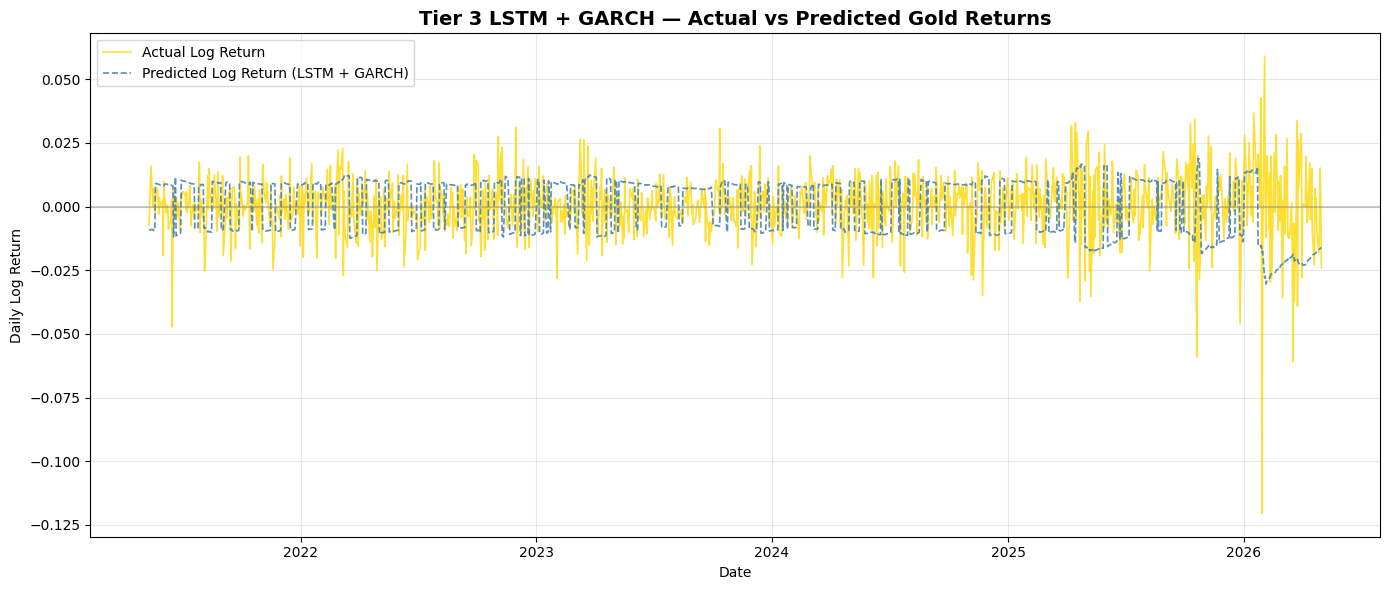


     NEXT DAY GOLD PREDICTION (LSTM + GARCH)
  Last Known Price    : $4629.90
  Probability Up      : 24.90%
  GARCH Vol Forecast  : 0.015810
  Combined Return     : -0.015810
  Predicted Price     : $4557.28
  Expected Move ($)   : $-72.62
  Direction           : DOWN


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import RobustScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Set Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Define Features & Targets
# Log_Return removed to prevent target leakage
# VIX_Change removed due to high correlation with VIX
# Volatility features added to improve magnitude prediction
lstm_features = [
    'Return_Lag1', 'Return_Lag2', 'Return_Lag3',
    'RSI14', 'ATR14', 'ATR_Ratio',
    'DXY_Return', 'VIX', 'TNX', 'TNX_Change', 'SP500_Return',
    'RealVol5', 'RealVol21',
    'AbsReturn_Lag1', 'AbsReturn_Lag2'
]

X     = gold[lstm_features]
y_raw = gold['Target_Return']
y_clf = np.where(y_raw >= 0, 1.0, 0.0)
y_mag = np.abs(y_raw.values)

# 3. Train/Test Split (80/20 Time Ordered)
split_idx = int(len(X) * 0.80)

X_train_raw, X_test_raw = X.iloc[:split_idx], X.iloc[split_idx:]

y_train_raw, y_test_raw = y_raw.iloc[:split_idx].values, y_raw.iloc[split_idx:].values
y_train_clf, y_test_clf = y_clf[:split_idx], y_clf[split_idx:]
y_train_mag, y_test_mag = y_mag[:split_idx], y_mag[split_idx:]

# 4. Scale Features
# RobustScaler consistent across all tiers, handles financial spikes better
scaler_lstm = RobustScaler()
X_train_scaled = scaler_lstm.fit_transform(X_train_raw)
X_test_scaled  = scaler_lstm.transform(X_test_raw)

# 5. GARCH Walk-Forward Volatility Forecast
# GJR-GARCH captures asymmetric volatility (larger spikes on negative shocks)
# Refitted at every test point on an expanding window to avoid lookahead bias
print("\nFitting walk-forward GJR-GARCH volatility forecasts...")

all_returns        = gold['Log_Return'] * 100  # Scale for numerical stability
garch_vol_forecast = []

for i in range(len(y_test_raw)):
    history = all_returns.iloc[:split_idx + i]

    try:
        garch = arch_model(history, vol='Garch', p=1, o=1, q=1, dist='normal')
        res   = garch.fit(disp='off', show_warning=False)
        fc    = res.forecast(horizon=1, reindex=False)
        sigma = np.sqrt(fc.variance.values[-1, 0]) / 100  # Back to decimal scale
    except Exception:
        # Fall back to recent realised volatility if fitting fails
        sigma = np.abs(history.iloc[-20:]).mean() / 100

    garch_vol_forecast.append(sigma)

    if i % 100 == 0:
        print(f"  Progress: {i}/{len(y_test_raw)} steps complete")

garch_vol_forecast = np.array(garch_vol_forecast)
print(f"GARCH forecast complete. Mean vol: {garch_vol_forecast.mean():.6f}")

# 6. Sequence Creation Function
# LOOKBACK is no longer fixed - Optuna will find the best value
def create_sequences(X, y_raw, y_clf, y_mag, lookback):
    Xs, y_raws, y_clfs, y_mags = [], [], [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        y_raws.append(y_raw[i])
        y_clfs.append(y_clf[i])
        y_mags.append(y_mag[i])
    return np.array(Xs), np.array(y_raws), np.array(y_clfs), np.array(y_mags)

# 7. Define LSTM Architecture
class GoldLSTM(nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, dropout):
        super(GoldLSTM, self).__init__()
        self.lstm1    = nn.LSTM(input_size, hidden_size_1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2    = nn.LSTM(hidden_size_1, hidden_size_2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.fc       = nn.Linear(hidden_size_2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out    = self.dropout1(out)
        out, _ = self.lstm2(out)
        out    = self.dropout2(out)
        out    = self.fc(out[:, -1, :])
        return out

# 8. Universal Training Function
def train_model(model, criterion, X_train, y_train, X_val, y_val,
                lr, batch_size, epochs, patience=5):
    dataset    = TensorDataset(X_train, y_train)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_weights     = None

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in dataloader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_weights)
    return model, best_val_loss

# 9. Stage 1: Optuna for Classifier (Direction)
# Optuna only ever sees the internal train/val split, never the test set
print("\nStage 1 — Running Optuna for Classifier LSTM (50 trials)...")

def objective_clf(trial):
    h1       = trial.suggest_int('hidden_size_1', 32, 128, step=32)
    h2       = trial.suggest_int('hidden_size_2', 16, 64,  step=16)
    dropout  = trial.suggest_float('dropout', 0.1, 0.5)
    lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    lookback = trial.suggest_int('lookback', 5, 30, step=5)

    X_tr_seq, _, y_tr_clf_seq, _ = create_sequences(
        X_train_scaled, y_train_raw, y_train_clf, y_train_mag, lookback)

    val_split = int(len(X_tr_seq) * 0.80)
    X_tr_t  = torch.tensor(X_tr_seq[:val_split], dtype=torch.float32).to(device)
    X_val_t = torch.tensor(X_tr_seq[val_split:], dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr_clf_seq[:val_split], dtype=torch.float32).unsqueeze(1).to(device)
    y_val_t = torch.tensor(y_tr_clf_seq[val_split:], dtype=torch.float32).unsqueeze(1).to(device)

    model = GoldLSTM(len(lstm_features), h1, h2, dropout).to(device)
    _, val_loss = train_model(
        model, nn.BCEWithLogitsLoss(),
        X_tr_t, y_tr_t, X_val_t, y_val_t,
        lr=lr, batch_size=32, epochs=30, patience=5
    )
    return val_loss

study_clf = optuna.create_study(direction='minimize')
study_clf.optimize(objective_clf, n_trials=100)
best_c        = study_clf.best_params
best_lookback = best_c['lookback']
print(f"Best Classifier Params : {best_c}")
print(f"Best Lookback          : {best_lookback}")

# 10. Rebuild Final Sequences Using Best Lookback
# Both direction model and GARCH synthesis share the same lookback
X_train_seq, y_train_raw_seq, y_train_clf_seq, y_train_mag_seq = create_sequences(
    X_train_scaled, y_train_raw, y_train_clf, y_train_mag, best_lookback)
X_test_seq, y_test_raw_seq, y_test_clf_seq, y_test_mag_seq = create_sequences(
    X_test_scaled, y_test_raw, y_test_clf, y_test_mag, best_lookback)

val_split = int(len(X_train_seq) * 0.80)

X_tr  = torch.tensor(X_train_seq[:val_split], dtype=torch.float32).to(device)
X_val = torch.tensor(X_train_seq[val_split:], dtype=torch.float32).to(device)

y_tr_clf  = torch.tensor(y_train_clf_seq[:val_split], dtype=torch.float32).unsqueeze(1).to(device)
y_val_clf = torch.tensor(y_train_clf_seq[val_split:], dtype=torch.float32).unsqueeze(1).to(device)

X_train_tensor     = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
X_test_tensor      = torch.tensor(X_test_seq,  dtype=torch.float32).to(device)
y_train_clf_tensor = torch.tensor(y_train_clf_seq, dtype=torch.float32).unsqueeze(1).to(device)

# 11. Train Final Classifier on Full Training Set
clf_model = GoldLSTM(len(lstm_features), best_c['hidden_size_1'],
                     best_c['hidden_size_2'], best_c['dropout']).to(device)

clf_model, _ = train_model(
    clf_model, nn.BCEWithLogitsLoss(),
    X_train_tensor, y_train_clf_tensor,
    X_val, y_val_clf,
    lr=best_c['lr'], batch_size=32, epochs=100, patience=10
)

clf_model.eval()
with torch.no_grad():
    clf_probs  = torch.sigmoid(clf_model(X_test_tensor)).cpu().numpy().flatten()
    y_pred_clf = np.where(clf_probs > 0.5, 1, 0)

dir_accuracy = accuracy_score(y_test_clf_seq, y_pred_clf) * 100
print(f"Final Directional Accuracy: {dir_accuracy:.2f}%")

# 12. Synthesis: LSTM Direction + GARCH Magnitude
# Trim GARCH forecasts to match sequence length lost from lookback window
garch_vol_seq      = garch_vol_forecast[best_lookback:]
direction_multipliers      = np.where(y_pred_clf == 1, 1, -1)
final_combined_predictions = direction_multipliers * garch_vol_seq

combined_mae  = mean_absolute_error(y_test_raw_seq, final_combined_predictions)
combined_rmse = np.sqrt(mean_squared_error(y_test_raw_seq, final_combined_predictions))

# 12b. Big Move Accuracy
# Evaluates directional accuracy on the top 20% largest actual moves
threshold    = np.percentile(np.abs(y_test_raw_seq), 80)
big_move_idx = np.abs(y_test_raw_seq) > threshold
big_move_acc = accuracy_score(
    np.sign(y_test_raw_seq[big_move_idx]),
    np.sign(final_combined_predictions[big_move_idx])
)

print("\n" + "=" * 50)
print(" TIER 4 MODEL PERFORMANCE (LSTM + GARCH)")
print("=" * 50)
print(f" Best Lookback           : {best_lookback} days")
print(f" Direction Accuracy      : {dir_accuracy:.2f}%")
print(f" Big Move Accuracy (80th): {big_move_acc:.2%}")
print(f" Combined MAE            : {combined_mae:.6f}")
print(f" Combined RMSE           : {combined_rmse:.6f}")
print("=" * 50)

# 13. Plot Predicted vs Actual
test_dates = X_test_raw.index[best_lookback:]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_raw_seq,
         label='Actual Log Return', color='gold', linewidth=1.2, alpha=0.8)
plt.plot(test_dates, final_combined_predictions,
         label='Predicted Log Return (LSTM + GARCH)', color='steelblue',
         linewidth=1.2, linestyle='--', alpha=0.9)

plt.axhline(0, color='gray', linestyle='-', alpha=0.4)
plt.title('Tier 4 LSTM + GARCH — Actual vs Predicted Gold Returns',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Log Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 14. Next Day Prediction
# GARCH next day forecast uses all available data
last_sequence = scaler_lstm.transform(X_test_raw.tail(best_lookback))
last_sequence = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0).to(device)

# Direction from LSTM
clf_model.eval()
with torch.no_grad():
    prob_up  = torch.sigmoid(clf_model(last_sequence)).item()
    pred_dir = 1 if prob_up > 0.5 else -1

# Magnitude from GARCH fitted on all available data
try:
    garch_final = arch_model(all_returns, vol='Garch', p=1, o=1, q=1, dist='normal')
    res_final   = garch_final.fit(disp='off', show_warning=False)
    fc_final    = res_final.forecast(horizon=1, reindex=False)
    pred_mag    = np.sqrt(fc_final.variance.values[-1, 0]) / 100
except Exception:
    pred_mag = garch_vol_forecast[-1]  # Fall back to last forecast

combined_predicted_return = pred_dir * pred_mag
last_known_price          = float(gold['Close'].iloc[-1])
next_day_price            = last_known_price * np.exp(combined_predicted_return)
direction_str             = "UP" if prob_up > 0.5 else "DOWN"

print("\n" + "=" * 50)
print("     NEXT DAY GOLD PREDICTION (LSTM + GARCH)")
print("=" * 50)
print(f"  Last Known Price    : ${last_known_price:.2f}")
print(f"  Probability Up      : {prob_up:.2%}")
print(f"  GARCH Vol Forecast  : {pred_mag:.6f}")
print(f"  Combined Return     : {combined_predicted_return:.6f}")
print(f"  Predicted Price     : ${next_day_price:.2f}")
print(f"  Expected Move ($)   : ${next_day_price - last_known_price:.2f}")
print(f"  Direction           : {direction_str}")
print("=" * 50)

Training set : 2000-11-22 to 2021-04-06 (5098 rows)
Testing set  : 2021-04-07 to 2026-05-04 (1275 rows)

Fitting walk-forward GJR-GARCH volatility forecasts...
  Progress: 0/1275 steps complete
  Progress: 100/1275 steps complete
  Progress: 200/1275 steps complete
  Progress: 300/1275 steps complete
  Progress: 400/1275 steps complete
  Progress: 500/1275 steps complete
  Progress: 600/1275 steps complete
  Progress: 700/1275 steps complete
  Progress: 800/1275 steps complete
  Progress: 900/1275 steps complete
  Progress: 1000/1275 steps complete
  Progress: 1100/1275 steps complete
  Progress: 1200/1275 steps complete
GARCH forecast complete. Mean vol: 0.010695

Running Optuna for XGBoost Classifier (100 trials)...
XGBoost Direction Accuracy: 55.22%

 TIER 5 MODEL PERFORMANCE (XGBOOST + GARCH)
 Direction Accuracy      : 55.22%
 Big Move Accuracy (80th): 52.16%
 Combined MAE            : 0.011795
 Combined RMSE           : 0.015740


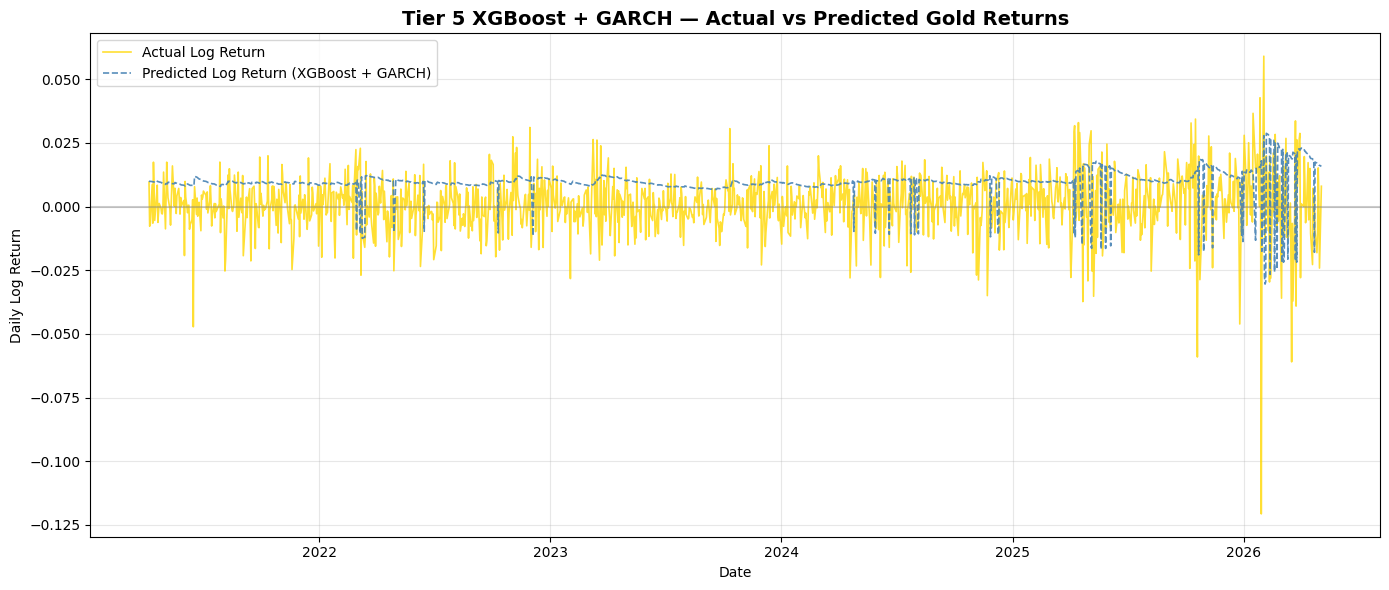


     NEXT DAY GOLD PREDICTION (TIER 5 XGBOOST + GARCH)
  Last Known Price    : $4519.50
  Probability Up      : 53.50%
  GARCH Vol Forecast  : 0.016033
  Combined Return     : 0.016033
  Predicted Price     : $4592.55
  Expected Move ($)   : $73.05
  Direction           : UP


In [ ]:
# 1. Define Features & Targets
# Log_Return removed to prevent target leakage
# VIX_Change removed due to high correlation with VIX
features = [
    'Return_Lag1', 'Return_Lag2', 'Return_Lag3',
    'RSI14', 'ATR14', 'ATR_Ratio',
    'DXY_Return', 'VIX', 'TNX', 'TNX_Change', 'SP500_Return',
    'RealVol5', 'RealVol21',
    'AbsReturn_Lag1', 'AbsReturn_Lag2'
]

X     = gold[features]
y_raw = gold['Target_Return']
y_clf = gold['Target_Direction']

# 2. Train/Test Split (80/20 Time Ordered)
split_idx = int(len(X) * 0.80)

X_train,     X_test     = X.iloc[:split_idx],     X.iloc[split_idx:]
y_train_clf, y_test_clf = y_clf.iloc[:split_idx], y_clf.iloc[split_idx:]
y_test_raw              = y_raw.iloc[split_idx:]

print(f"Training set : {X_train.index[0].date()} to {X_train.index[-1].date()} ({len(X_train)} rows)")
print(f"Testing set  : {X_test.index[0].date()} to {X_test.index[-1].date()} ({len(X_test)} rows)")

# 3. Scale Features
# RobustScaler consistent across all tiers, handles financial spikes better
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. GARCH Walk-Forward Volatility Forecast
# GJR-GARCH captures asymmetric volatility (larger spikes on negative shocks)
# Refitted at every test point on an expanding window to avoid lookahead bias
print("\nFitting walk-forward GJR-GARCH volatility forecasts...")

all_returns        = gold['Log_Return'] * 100  # Scale for numerical stability
garch_vol_forecast = []

for i in range(len(y_test_raw)):
    history = all_returns.iloc[:split_idx + i]

    try:
        garch = arch_model(history, vol='Garch', p=1, o=1, q=1, dist='normal')
        res   = garch.fit(disp='off', show_warning=False)
        fc    = res.forecast(horizon=1, reindex=False)
        sigma = np.sqrt(fc.variance.values[-1, 0]) / 100
    except Exception:
        # Fall back to recent realised volatility if fitting fails
        sigma = np.abs(history.iloc[-20:]).mean() / 100

    garch_vol_forecast.append(sigma)

    if i % 100 == 0:
        print(f"  Progress: {i}/{len(y_test_raw)} steps complete")

garch_vol_forecast = np.array(garch_vol_forecast)
print(f"GARCH forecast complete. Mean vol: {garch_vol_forecast.mean():.6f}")

# 5. XGBoost Direction: Optuna Hyperparameter Search
# TimeSeriesSplit ensures Optuna never touches the test set during tuning
tscv = TimeSeriesSplit(n_splits=5)

def objective_clf(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 2, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 1.0),
        'objective'        : 'binary:logistic',
        'eval_metric'      : 'logloss',
        'random_state'     : 42,
        'tree_method'      : 'hist'
    }
    fold_scores = []
    for train_idx, val_idx in tscv.split(X_train_scaled):
        model = xgb.XGBClassifier(**params)
        model.fit(X_train_scaled[train_idx], y_train_clf.iloc[train_idx], verbose=False)
        preds = model.predict(X_train_scaled[val_idx])
        fold_scores.append(accuracy_score(y_train_clf.iloc[val_idx], preds))
    return np.mean(fold_scores)

print("\nRunning Optuna for XGBoost Classifier (100 trials)...")
study_clf = optuna.create_study(direction='maximize')
study_clf.optimize(objective_clf, n_trials=100)

best_clf_params = study_clf.best_params
best_clf_params.update({
    'objective'   : 'binary:logistic',
    'eval_metric' : 'logloss',
    'random_state': 42,
    'tree_method' : 'hist'
})

# Retrain on full training set with best params before evaluating on test set
xgb_clf = xgb.XGBClassifier(**best_clf_params)
xgb_clf.fit(X_train_scaled, y_train_clf)

y_pred_clf   = xgb_clf.predict(X_test_scaled)
dir_accuracy = accuracy_score(y_test_clf, y_pred_clf) * 100
print(f"XGBoost Direction Accuracy: {dir_accuracy:.2f}%")

# 6. Synthesis: XGBoost Direction + GARCH Magnitude
# No trimming needed as XGBoost has no lookback window unlike the LSTM
direction_multipliers      = np.where(y_pred_clf == 1, 1, -1)
final_combined_predictions = direction_multipliers * garch_vol_forecast

combined_mae  = mean_absolute_error(y_test_raw, final_combined_predictions)
combined_rmse = np.sqrt(mean_squared_error(y_test_raw, final_combined_predictions))

# 7. Big Move Accuracy
# Evaluates directional accuracy on the top 20% largest actual moves
threshold    = np.percentile(np.abs(y_test_raw), 80)
big_move_idx = np.abs(y_test_raw) > threshold
big_move_acc = accuracy_score(
    np.sign(y_test_raw.values[big_move_idx]),
    np.sign(final_combined_predictions[big_move_idx])
)

print("\n" + "=" * 50)
print(" TIER 5 MODEL PERFORMANCE (XGBOOST + GARCH)")
print("=" * 50)
print(f" Direction Accuracy      : {dir_accuracy:.2f}%")
print(f" Big Move Accuracy (80th): {big_move_acc:.2%}")
print(f" Combined MAE            : {combined_mae:.6f}")
print(f" Combined RMSE           : {combined_rmse:.6f}")
print("=" * 50)

# 8. Plot Predicted vs Actual
plt.figure(figsize=(14, 6))

plt.plot(y_test_raw.index, y_test_raw.values,
         color='gold', linewidth=1.2, alpha=0.8, label='Actual Log Return')
plt.plot(y_test_raw.index, final_combined_predictions,
         color='steelblue', linewidth=1.2, linestyle='--', alpha=0.9,
         label='Predicted Log Return (XGBoost + GARCH)')

plt.axhline(0, color='gray', linestyle='-', alpha=0.4)
plt.title('Tier 5 XGBoost + GARCH — Actual vs Predicted Gold Returns',
          fontsize=14, fontweight='bold')
plt.ylabel('Daily Log Return')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Next Day Prediction
# Direction from XGBoost on latest available features
last_row        = X.iloc[[-1]]
last_row_scaled = scaler.transform(last_row)

prob_up        = xgb_clf.predict_proba(last_row_scaled)[0][1]
pred_dir       = 1 if prob_up > 0.5 else -1

# Magnitude from GARCH fitted on all available data
try:
    garch_final = arch_model(all_returns, vol='Garch', p=1, o=1, q=1, dist='normal')
    res_final   = garch_final.fit(disp='off', show_warning=False)
    fc_final    = res_final.forecast(horizon=1, reindex=False)
    pred_mag    = np.sqrt(fc_final.variance.values[-1, 0]) / 100
except Exception:
    pred_mag = garch_vol_forecast[-1]

combined_predicted_return = pred_dir * pred_mag
last_known_price          = float(gold['Close'].iloc[-1])
next_day_price            = last_known_price * np.exp(combined_predicted_return)
direction_str             = "UP" if prob_up > 0.5 else "DOWN"

print("\n" + "=" * 50)
print("     NEXT DAY GOLD PREDICTION (TIER 5 XGBOOST + GARCH)")
print("=" * 50)
print(f"  Last Known Price    : ${last_known_price:.2f}")
print(f"  Probability Up      : {prob_up:.2%}")
print(f"  GARCH Vol Forecast  : {pred_mag:.6f}")
print(f"  Combined Return     : {combined_predicted_return:.6f}")
print(f"  Predicted Price     : ${next_day_price:.2f}")
print(f"  Expected Move ($)   : ${next_day_price - last_known_price:.2f}")
print(f"  Direction           : {direction_str}")
print("=" * 50)

Five model configurations are evaluated across a common test set spanning approximately 2021 to 2026, with all models trained on an 80% chronological split of daily gold futures data from December 2000. The results reveal a consistent and interpretable pattern: direction prediction is the primary bottleneck across all architectures, magnitude estimation is more tractable and responds well to dedicated volatility modelling, and the combination of XGBoost direction classification with GJR-GARCH magnitude forecasting produces the strongest overall performance.

The base model establishes the linear benchmark and fails to beat random chance, achieving a directional accuracy of 48.60% on the test set. Walk-forward validation across five folds of the training set returns a mean accuracy of 50.11% with a standard deviation of 3.31%, confirming that the logistic regression finds no stable linear signal for direction across different market regimes. The magnitude component compounds this further, with the linear regression collapsing to a near-constant prediction close to the mean absolute return, producing predicted peaks of identical height regardless of actual market conditions. This flat magnitude behaviour is a direct consequence of minimising mean absolute error on a heavily right-skewed distribution of return magnitudes, where predicting the median small move is mathematically cheaper than attempting to capture rare large ones. The base model result is not simply a modelling failure. It is consistent with the efficient market hypothesis, which predicts that linear combinations of lagged returns and macro indicators should carry negligible directional signal at daily frequency.

XGBoost improves on this substantially by capturing non-linear feature interactions and selecting the most informative signals at each decision split rather than assuming globally linear relationships. With Optuna hyperparameter tuning conducted correctly within the training set using TimeSeriesSplit cross-validation, the XGBoost classifier achieves a directional accuracy of 55.69% and a big move accuracy of 52.55% on the top 20% of days by actual return magnitude. These are the strongest directional results across all five models. However the magnitude regressor exhibits the same flat peak behaviour as the base model, confirming that the two-stage decomposition design rather than the choice of model is the primary constraint on magnitude estimation. Gradient boosting minimises MAE just as aggressively as linear regression when the target distribution is skewed, converging toward a conservative central estimate rather than attempting to capture tail moves.

The LSTM results are particularly instructive regarding the appropriateness of sequential architectures for this problem. Despite the theoretical advantage of processing temporal sequences, the standalone LSTM achieves a directional accuracy of 51.26% and a big move accuracy of 48.43%, both below XGBoost. The most revealing finding is that Optuna consistently selects the shortest available lookback window of 5 days from a search space of 5 to 30 days across multiple independent runs. This is a strong empirical signal that gold daily returns carry almost no exploitable sequential structure beyond the very recent past. At a 5 day lookback the LSTM effectively discards most of its memory and operates closer to a shallow feedforward network on a minimal input window, which raises a fundamental question about whether a recurrent architecture is appropriate for this problem at all. This outcome is consistent with the well-documented finding in quantitative finance literature that gradient boosting methods tend to outperform recurrent neural networks on tabular financial data where sequential dependencies are weak, precisely because XGBoost's feature selection mechanism is better suited to identifying sparse signals in noisy data than an LSTM's sequential memory.

The LSTM + GARCH hybrid demonstrates the value of dedicated volatility modelling but is constrained by the LSTM direction classifier. Replacing the LSTM magnitude regressor with a walk-forward GJR-GARCH model produces a MAE of 0.012805, an improvement over the standalone LSTM's 0.012415, though the direction accuracy of 48.96% falls below random chance. The fundamental problem is that a well-calibrated magnitude estimate paired with a poor direction classifier produces predictions that are precisely wrong rather than approximately right. When the model correctly estimates that tomorrow will be a large move but incorrectly predicts the direction, the combined prediction incurs a larger error than a conservative near-zero estimate would. This explains why the LSTM + GARCH hybrid does not translate its magnitude advantage into better combined performance despite GARCH's demonstrable superiority as a volatility estimator.

The XGBoost + GARCH hybrid resolves this by pairing the two strongest individual components identified across all experiments. XGBoost direction classification, which achieves 55.22% accuracy on the test set, is combined with walk-forward GJR-GARCH magnitude forecasting. The GJR-GARCH specification is particularly appropriate for gold as it accommodates asymmetric volatility responses, whereby negative shocks such as risk-off events and dollar strength tend to produce larger volatility increases than positive shocks of equivalent magnitude. The combined model achieves a MAE of 0.011795 and an RMSE of 0.015740, the strongest performance on both error metrics across all five configurations. The RMSE improvement over standalone XGBoost is particularly meaningful since RMSE penalises large errors more heavily than MAE, and the XGBoost + GARCH model's lower RMSE indicates that its predictions are better distributed around actual values rather than clustered conservatively near zero as the standalone XGBoost magnitude regressor tends to be. It is worth noting that standalone XGBoost records a marginally lower MAE of 0.010043, which reflects its conservative magnitude predictions being penalised less on average across the many small-move days that dominate the distribution. On the days that matter most, specifically the large moves captured by the big move accuracy metric, XGBoost + GARCH and standalone XGBoost perform comparably at 52.16% and 52.55% respectively, suggesting the primary gain from GARCH is in magnitude calibration across the full return distribution rather than exclusively on tail events.

Taken together, the results demonstrate that the prediction problem decomposes naturally into two sub-problems with different tractability. Direction prediction remains largely unsolved at daily frequency across all architectures tested, with no model exceeding 55.69% accuracy and big move accuracy clustering between 47% and 53% across all tiers, a range that is difficult to distinguish from noise at this sample size. Magnitude prediction is more tractable and responds directly to dedicated volatility modelling, with GARCH consistently outperforming learned regressors by exploiting the well-established property of volatility clustering in financial return series. The practical implication is that the XGBoost + GARCH architecture represents a principled separation of concerns, delegating direction to the model best suited to non-linear tabular classification and magnitude to the model best suited to conditional variance forecasting, rather than asking a single architecture to solve both problems simultaneously. Further improvement in combined performance would most likely require qualitatively richer features with genuine directional signal, such as options market implied volatility skew, central bank positioning data, or high frequency news sentiment, or a shift toward lower prediction frequency where macro relationships have more time to manifest in price and the signal-to-noise ratio improves accordingly.